In [139]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from Bio import SeqIO
import matplotlib.pyplot as plt
from Bio.Data import CodonTable
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from statsmodels.stats.multitest import multipletests
from sklearn.mixture import GaussianMixture
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, roc_curve, precision_recall_curve, auc, accuracy_score
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [143]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
def read_gene_expression(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df

def read_somatic_mutations(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df

def read_patient_metadata(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df


def handle_missing_data(df: pd.DataFrame,
                        subset_cols: list = None,
                        method: str = "drop") -> pd.DataFrame:

    if method == "drop":
        if subset_cols:
            return df.dropna(subset=subset_cols)
        return df.dropna()
    elif method == "fill":
        numeric = df.select_dtypes(include=[np.number]).columns
        df[numeric] = df[numeric].fillna(df[numeric].mean())
        return df
    else:
        raise ValueError("method must be 'drop' or 'fill'")

def kaplan_meier_survival(df: pd.DataFrame,
                          time_col: str = 'DSS.time',
                          event_col: str = 'DSS') -> KaplanMeierFitter:

    km_df = df[[time_col, event_col]].copy()
    km_df[time_col] = pd.to_numeric(km_df[time_col], errors='coerce')
    km_df[event_col] = pd.to_numeric(km_df[event_col], errors='coerce')
    km_df = handle_missing_data(km_df, subset_cols=[time_col, event_col], method="drop")
    if km_df.empty:
        raise ValueError("No data left for KM after cleaning")
    kmf = KaplanMeierFitter()
    kmf.fit(durations=km_df[time_col], event_observed=km_df[event_col])
    kmf.plot_survival_function()
    return kmf

def cox_proportional_hazards(df: pd.DataFrame,
                             time_col: str,
                             event_col: str,
                             numeric_covs: list,
                             categorical_covs: list) -> CoxPHFitter:

    cph_df = df[[time_col, event_col] + numeric_covs + categorical_covs].copy()
    cph_df[time_col] = pd.to_numeric(cph_df[time_col], errors='coerce')
    cph_df[event_col] = pd.to_numeric(cph_df[event_col], errors='coerce')
    cph_df = handle_missing_data(cph_df, subset_cols=[time_col, event_col] + numeric_covs, method="drop")
    if cph_df.empty:
        raise ValueError("No data left for CoxPH after cleaning")
    cph_df = pd.get_dummies(cph_df, columns=categorical_covs, drop_first=True)
    cph = CoxPHFitter()
    cph.fit(cph_df, duration_col=time_col, event_col=event_col)
    return cph

def add_mutation_status_column(df: pd.DataFrame,
                               gene_col: str = 'Hugo_Symbol',
                               mutation_gene: str = 'TP53') -> pd.DataFrame:

    df = df.copy()
    df['mutation_status'] = np.where(df[gene_col] == mutation_gene,
                                     'mutant',
                                     'wildtype')
    return df


def compute_tmb(somatic_mut: pd.DataFrame) -> pd.Series:
    tmb = somatic_mut['patient_id'].value_counts()
    tmb.name = 'TMB'
    return tmb

Log10 split: 2.858
Exact split: 721 mutations


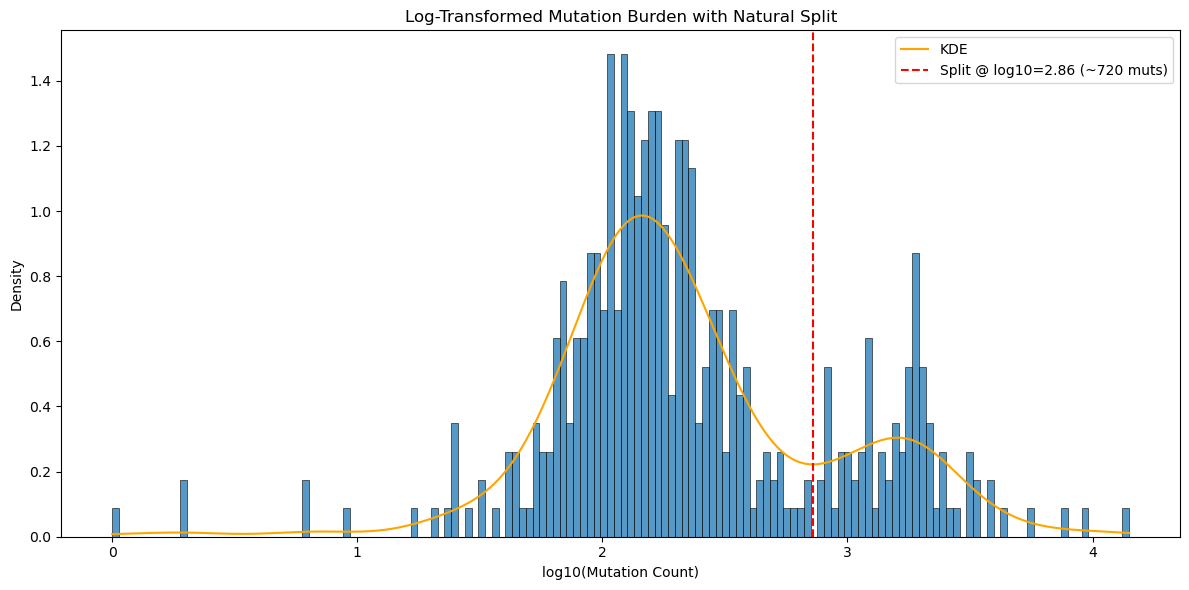

In [4]:
somatic_mut = read_somatic_mutations("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.mutations.txt")
mutation_counts = somatic_mut['patient_id'].value_counts().sort_index()
counts_array = mutation_counts[mutation_counts > 0].values.astype(float)
log_counts = np.log10(counts_array)

kde = gaussian_kde(log_counts)
x_vals = np.linspace(log_counts.min(), log_counts.max(), 1000)
kde_vals = kde(x_vals)
mask = (x_vals > 1.5) & (x_vals < 3.5)
x_zoom = x_vals[mask]
kde_zoom = kde_vals[mask]

# Find trough (local minimum)
troughs, _ = find_peaks(-kde_zoom)
if len(troughs) > 0:
    log_split = x_zoom[troughs[0]]
    exact_split = 10**log_split
    print(f"Log10 split: {log_split:.3f}")
    print(f"Exact split: {exact_split:.0f} mutations")
else:
    log_split = None
    print("No trough found.")

# Plot
plt.figure(figsize=(12, 6))
sns.histplot(log_counts, bins=150, kde=False, stat="density")
plt.plot(x_vals, kde_vals, color='orange', label='KDE')

# Plot vertical line for the split
if log_split:
    plt.axvline(log_split, color='red', linestyle='--', label=f"Split @ log10={log_split:.2f} (~{int(exact_split)} muts)")

plt.xlabel("log10(Mutation Count)")
plt.ylabel("Density")
plt.title("Log-Transformed Mutation Burden with Natural Split")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
hist_bins = np.histogram_bin_edges(log_counts, bins=50)
linear_bins = 10 ** hist_bins
bin_aligned_split = linear_bins[linear_bins < exact_split].max()
print(f"Adjusted split (previous bin edge): {bin_aligned_split:.0f} mutations")

Adjusted split (previous bin edge): 663 mutations


In [6]:
threshold = bin_aligned_split
mutation_counts = somatic_mut['patient_id'].value_counts().sort_index()
mutation_split_df = mutation_counts.to_frame(name="mutation_count")

# Assign groups
mutation_split_df["mutation_group"] = mutation_split_df["mutation_count"].apply(
    lambda x: "High" if x >= threshold else "Low"
)

# Split into patient ID lists
low_patients = mutation_split_df[mutation_split_df["mutation_group"] == "Low"].index.tolist()
high_patients = mutation_split_df[mutation_split_df["mutation_group"] == "High"].index.tolist()

# Filter original mutation rows
low_mut = somatic_mut[somatic_mut['patient_id'].isin(low_patients)]
high_mut = somatic_mut[somatic_mut['patient_id'].isin(high_patients)]

In [7]:
expression = pd.read_csv("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.expression.txt", sep="\t")
expression.set_index(["patient_id"], inplace=True)
expression = expression.drop("sample_id", axis=1)
expression = expression.fillna(0)
metadata = pd.read_csv("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.metadata.txt", sep="\t")
metadata.set_index("patient_id", inplace=True)

In [8]:
metadata.shape

(415, 18)

In [9]:
metadata.OS.value_counts()

OS
0.0    255
1.0    160
Name: count, dtype: int64

# All DFI

(187, 2443)
(186, 2443)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 10, 'solver': 'lbfgs'}

Training SVM...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.860606  0.657445  0.803571        0.0  0.000000   
1  Logistic Regression  0.838384  0.496354  0.803571        0.5  0.363636   
2                  SVM  0.844444  0.511192  0.803571        0.5  0.363636   

         F1  
0  0.000000  
1  0.421053  
2  0.421053  


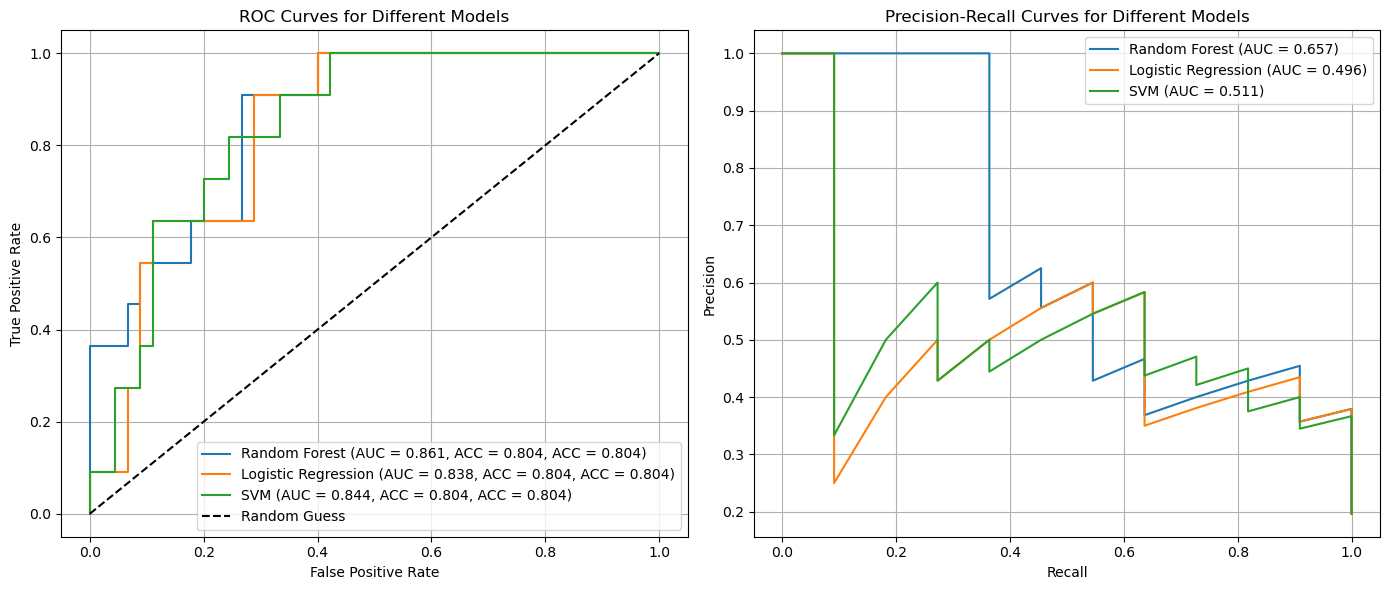

In [144]:
low_mut_metadata = metadata
low_mut_patients = set(low_mut_metadata.index)
low_mutation_matrix = pd.crosstab(
    index=low_mut['patient_id'],
    columns=low_mut['Hugo_Symbol'],
    values=1, 
    aggfunc='count'
)
low_mutation_matrix = low_mutation_matrix.fillna(0)
low_mutation_matrix = low_mutation_matrix[low_mutation_matrix.index.isin(low_mut_patients)]
low_exp_matrix = expression[expression.index.isin(low_mut_patients)]

low_metadata = low_mut_metadata.dropna(subset=['DFI', 'DFI.time'])
low_metadata['y'] = low_metadata['DFI']

common_patients = low_metadata.index.intersection(low_mutation_matrix.index).intersection(low_exp_matrix.index)
X_mut = low_mutation_matrix.loc[common_patients]
X_exp = low_exp_matrix.loc[common_patients]
X_clinical = low_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                 'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                 'histological_grade', 'tumor_status']]
y = low_metadata.loc[common_patients, 'y']

# Step 3: Feature Selection
# 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
mutation_freq = X_mut.mean()
selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
X_mut_selected = X_mut[selected_mut_genes]

# 3.2: Gene Expression Features - Standardize and filter low-variance genes
scaler = StandardScaler()
X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
exp_variance = X_exp_scaled.var()
selected_exp_genes = exp_variance[exp_variance > 0.01].index
X_exp_selected = X_exp_scaled[selected_exp_genes]

# 3.3: Clinical Features - Encode categorical variables
# Define which columns are categorical
categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
numerical_cols = ['age_at_initial_pathologic_diagnosis']

# Use ColumnTransformer to encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

X_clinical_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_clinical),
    index=X_clinical.index,
    columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
)

# 3.4: Univariate Feature Selection for Mutation and Expression Features
# For binary features (mutation), use chi-squared test
mut_p_values = {}
for col in X_mut_selected.columns:
    contingency_table = pd.crosstab(X_mut_selected[col], y)
    chi2, p, _, _ = chi2_contingency(contingency_table)
    mut_p_values[col] = p

# t-test
exp_p_values = {}
for col in X_exp_selected.columns:
    group0 = X_exp_selected[col][y == 0]
    group1 = X_exp_selected[col][y == 1]
    t_stat, p = ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
    exp_p_values[col] = p

# Select features
selected_mut_features = [col for col, p in mut_p_values.items() if p < 0.1]
selected_exp_features = [col for col, p in exp_p_values.items() if p < 0.1]
X_mut_final = X_mut_selected[selected_mut_features]
X_exp_final = X_exp_selected[selected_exp_features]

X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)
print(X.shape)

X = X.dropna()
print(X.shape)

y = y[y.index.isin(X.index)]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Sanitize feature names to remove problematic characters (e.g., [], <)
X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

# Step 5: Train Multiple Models with Cross-Validation
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
    'SVM': SVC(probability=True, random_state=42),
    # 'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    # 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    # 'KNN': KNeighborsClassifier(),
    # 'Decision Tree': DecisionTreeClassifier(random_state=42)
}
# Hyperparameter grids for tuning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 200, 250, 300],
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 3, 4, 5]
    },
    'Logistic Regression': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
    },
    'SVM': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'kernel': ['rbf', 'linear']
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 3, 4, 5],
        'min_samples_leaf': [1, 2, 3]
    }
}

# Dictionary to store the best models and their performance
best_models = {}
metrics = {'Model': [], 'AUC-ROC': [], 'AUC-PR': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
roc_data = {}
pr_data = {}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    print(f"Best parameters for {model_name}:", grid_search.best_params_)
    
    # Predictions and probabilities
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)
    
    # Compute metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[model_name] = (fpr, tpr, auc_roc, accuracy)
    
    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    auc_pr = auc(recall_vals, precision_vals)
    pr_data[model_name] = (recall_vals, precision_vals, auc_pr)
    
    # Store metrics
    metrics['Model'].append(model_name)
    metrics['AUC-ROC'].append(auc_roc)
    metrics['AUC-PR'].append(auc_pr)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1'].append(f1)

# Print metrics in a table
metrics_df = pd.DataFrame(metrics)
print("\nModel Performance Comparison:")
print(metrics_df)

# Plot ROC and Precision-Recall Curves side by side
plt.figure(figsize=(14, 6))

# ROC Curves (Left subplot)
plt.subplot(1, 2, 1)
for model_name, (fpr, tpr, auc_roc, acc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.3f}, ACC = {acc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend()
plt.grid()

# Precision-Recall Curves (Right subplot)
plt.subplot(1, 2, 2)
for model_name, (recall_vals, precision_vals, auc_pr) in pr_data.items():
    plt.plot(recall_vals, precision_vals, label=f'{model_name} (AUC = {auc_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Different Models')
plt.legend()
plt.grid()

# Adjust layout and save
plt.tight_layout()
plt.show()

In [134]:
for model_name in ['Random Forest']:
    if model_name in best_models:
        print(f"\nTop 10 Most Important Features for {model_name}:")
        model = best_models[model_name]
        feature_importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
        print(feature_importance.head(20))


Top 10 Most Important Features for Random Forest:
tumor_status_WITH TUMOR    0.064113
PTPRT|11122                0.020063
SLC35F3|148641             0.012807
KBTBD13|390594             0.010703
SIPA1L2|57568              0.008056
ODF3|113746                0.007713
TTN|7273                   0.007598
SELV|348303                0.007088
LOC147727|147727           0.006971
SNAPC4|6621                0.006591
EXD1|161829                0.006034
NTRK3|4916                 0.005990
GTSF1L|149699              0.005631
LOC144486|144486           0.005594
GUCY2F|2986                0.005485
RPL29P2|118432             0.005336
LRTM2|654429               0.005311
CLDND1|56650               0.005288
SH2D3A|10045               0.005142
TP53INP1|94241             0.005038
dtype: float64


/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_35406/3384906078.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')


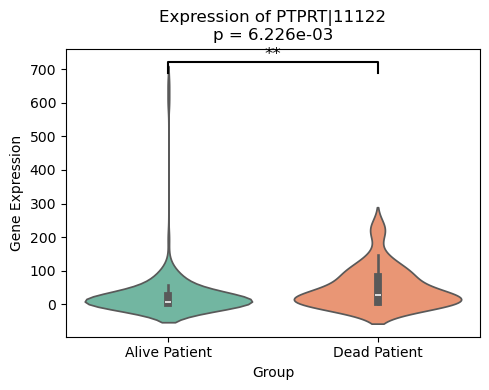

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_35406/3384906078.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')


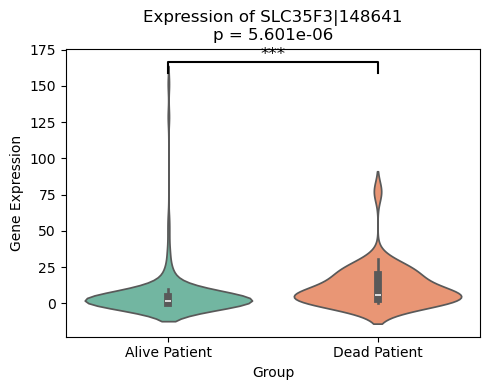

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_35406/3384906078.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')


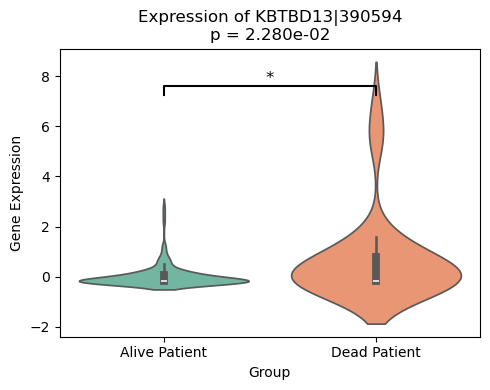

In [135]:
genes = ['PTPRT|11122', 'SLC35F3|148641', 'KBTBD13|390594']
for gene_id in genes:
    # Subset to get expression values as Series (1D)
    alive = low_exp_matrix[low_exp_matrix.index.isin(y[y == 0].index)][gene_id].squeeze()
    dead = low_exp_matrix[low_exp_matrix.index.isin(y[y == 1].index)][gene_id].squeeze()

    # Prepare DataFrame for plotting
    plot_df = pd.DataFrame({
        'Gene Expression': pd.concat([alive, dead]),
        'Group': ['Alive Patient'] * len(alive) + ['Dead Patient'] * len(dead)
    })

    # Perform Mann-Whitney U test
    stat, p_value = mannwhitneyu(alive, dead, alternative='two-sided')

    # Determine significance marker
    if p_value < 0.001:
        sig_marker = '***'
    elif p_value < 0.01:
        sig_marker = '**'
    elif p_value < 0.05:
        sig_marker = '*'
    else:
        sig_marker = 'ns'  # Not significant

    # Plot
    plt.figure(figsize=(5, 4))
    sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')

    # Add significance annotation
    # Get y-axis limits to place the annotation
    y_max = plot_df['Gene Expression'].max()
    y_range = plot_df['Gene Expression'].max() - plot_df['Gene Expression'].min()
    y_pos = y_max + y_range * 0.1  # Position slightly above the highest violin

    # Draw a line connecting the two groups
    x1, x2 = 0, 1  # x positions for 'Alive Patient' and 'Dead Patient'
    plt.plot([x1, x1, x2, x2], [y_pos - y_range * 0.05, y_pos, y_pos, y_pos - y_range * 0.05], lw=1.5, color='black')

    # Add the significance marker above the line
    plt.text((x1 + x2) / 2, y_pos, sig_marker, ha='center', va='bottom', color='black', fontsize=12)

    # Customize plot
    plt.title(f"Expression of {gene_id}\np = {p_value:.3e}")
    plt.tight_layout()
    plt.show()

# All OS

(324, 2074)
(322, 2074)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 7, 'min_samples_split': 3, 'n_estimators': 300}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 8, 'solver': 'newton-cg'}

Training SVM...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.715738  0.604900  0.649485   0.647059  0.282051   
1  Logistic Regression  0.849691  0.813464  0.793814   0.806452  0.641026   
2                  SVM  0.836207  0.808033  0.804124   0.812500  0.666667   

         F1  
0  0.392857  
1  0.714286  
2  0.732394  


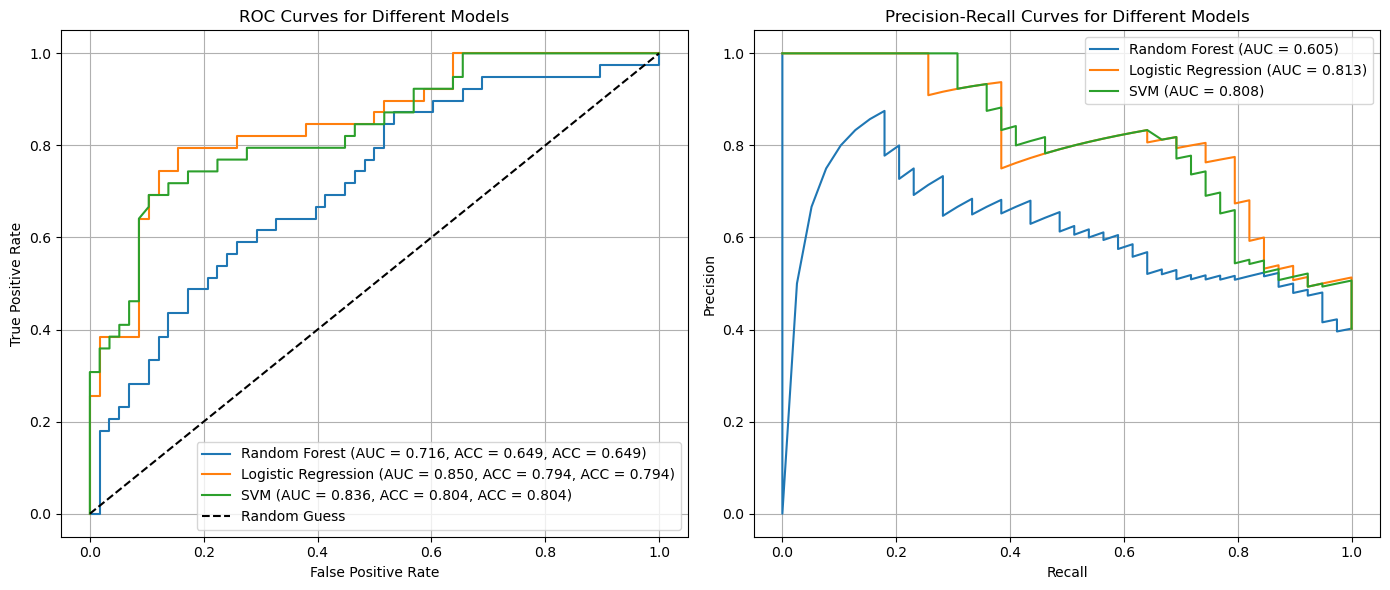

In [145]:
low_mut_metadata = metadata
low_mut_patients = set(low_mut_metadata.index)
low_mutation_matrix = pd.crosstab(
    index=low_mut['patient_id'],
    columns=low_mut['Hugo_Symbol'],
    values=1, 
    aggfunc='count'
)
low_mutation_matrix = low_mutation_matrix.fillna(0)
low_mutation_matrix = low_mutation_matrix[low_mutation_matrix.index.isin(low_mut_patients)]
low_exp_matrix = expression[expression.index.isin(low_mut_patients)]

low_metadata = low_mut_metadata.dropna(subset=['OS', 'OS.time'])
low_metadata['y'] = low_metadata['OS']

common_patients = low_metadata.index.intersection(low_mutation_matrix.index).intersection(low_exp_matrix.index)
X_mut = low_mutation_matrix.loc[common_patients]
X_exp = low_exp_matrix.loc[common_patients]
X_clinical = low_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                 'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                 'histological_grade', 'tumor_status']]
y = low_metadata.loc[common_patients, 'y']

# Step 3: Feature Selection
# 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
mutation_freq = X_mut.mean()
selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
X_mut_selected = X_mut[selected_mut_genes]

# 3.2: Gene Expression Features - Standardize and filter low-variance genes
scaler = StandardScaler()
X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
exp_variance = X_exp_scaled.var()
selected_exp_genes = exp_variance[exp_variance > 0.01].index
X_exp_selected = X_exp_scaled[selected_exp_genes]

# 3.3: Clinical Features - Encode categorical variables
# Define which columns are categorical
categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
numerical_cols = ['age_at_initial_pathologic_diagnosis']

# Use ColumnTransformer to encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

X_clinical_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_clinical),
    index=X_clinical.index,
    columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
)

# 3.4: Univariate Feature Selection for Mutation and Expression Features
# For binary features (mutation), use chi-squared test
mut_p_values = {}
for col in X_mut_selected.columns:
    contingency_table = pd.crosstab(X_mut_selected[col], y)
    chi2, p, _, _ = chi2_contingency(contingency_table)
    mut_p_values[col] = p

# t-test
exp_p_values = {}
for col in X_exp_selected.columns:
    group0 = X_exp_selected[col][y == 0]
    group1 = X_exp_selected[col][y == 1]
    t_stat, p = ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
    exp_p_values[col] = p

# Select features
selected_mut_features = [col for col, p in mut_p_values.items() if p < 0.1]
selected_exp_features = [col for col, p in exp_p_values.items() if p < 0.1]
X_mut_final = X_mut_selected[selected_mut_features]
X_exp_final = X_exp_selected[selected_exp_features]

X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)
print(X.shape)

X = X.dropna()
print(X.shape)

y = y[y.index.isin(X.index)]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Sanitize feature names to remove problematic characters (e.g., [], <)
X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

# Step 5: Train Multiple Models with Cross-Validation
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
    'SVM': SVC(probability=True, random_state=42),
    # 'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    # 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    # 'KNN': KNeighborsClassifier(),
    # 'Decision Tree': DecisionTreeClassifier(random_state=42)
}
# Hyperparameter grids for tuning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 200, 250, 300],
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 3, 4, 5]
    },
    'Logistic Regression': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
    },
    'SVM': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'kernel': ['rbf', 'linear']
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 3, 4, 5],
        'min_samples_leaf': [1, 2, 3]
    }
}

# Dictionary to store the best models and their performance
best_models = {}
metrics = {'Model': [], 'AUC-ROC': [], 'AUC-PR': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
roc_data = {}
pr_data = {}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    print(f"Best parameters for {model_name}:", grid_search.best_params_)
    
    # Predictions and probabilities
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)
    
    # Compute metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[model_name] = (fpr, tpr, auc_roc, accuracy)
    
    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    auc_pr = auc(recall_vals, precision_vals)
    pr_data[model_name] = (recall_vals, precision_vals, auc_pr)
    
    # Store metrics
    metrics['Model'].append(model_name)
    metrics['AUC-ROC'].append(auc_roc)
    metrics['AUC-PR'].append(auc_pr)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1'].append(f1)

# Print metrics in a table
metrics_df = pd.DataFrame(metrics)
print("\nModel Performance Comparison:")
print(metrics_df)

# Plot ROC and Precision-Recall Curves side by side
plt.figure(figsize=(14, 6))

# ROC Curves (Left subplot)
plt.subplot(1, 2, 1)
for model_name, (fpr, tpr, auc_roc, acc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.3f}, ACC = {acc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend()
plt.grid()

# Precision-Recall Curves (Right subplot)
plt.subplot(1, 2, 2)
for model_name, (recall_vals, precision_vals, auc_pr) in pr_data.items():
    plt.plot(recall_vals, precision_vals, label=f'{model_name} (AUC = {auc_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Different Models')
plt.legend()
plt.grid()

# Adjust layout and save
plt.tight_layout()
plt.show()

In [126]:
for model_name in ['Random Forest']:
    if model_name in best_models:
        print(f"\nTop 10 Most Important Features for {model_name}:")
        model = best_models[model_name]
        feature_importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
        print(feature_importance.head(20))


Top 10 Most Important Features for Random Forest:
tumor_status_WITH TUMOR    0.008786
TSPO2|222642               0.005187
ZNF512B|57473              0.003999
PDS5B|23047                0.003308
EXT2|2132                  0.002809
C19orf26|255057            0.002786
C10orf25|220979            0.002706
CXCR4|7852                 0.002604
MGAT5|4249                 0.002591
GAMT|2593                  0.002508
CD59|966                   0.002399
SGSH|6448                  0.002395
PC|5091                    0.002344
LRRCC1|85444               0.002305
APLP2|334                  0.002284
GPC3|2719                  0.002209
MRPL12|6182                0.002188
TTPAL|79183                0.002174
CTNNAL1|8727               0.002147
CDC42EP2|10435             0.002145
dtype: float64


In [128]:
# dict(sorted(exp_p_values.items(), key=lambda x: x[1]))

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_35406/4176055470.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')


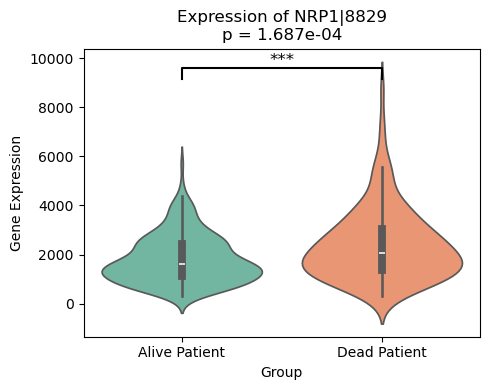

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_35406/4176055470.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')


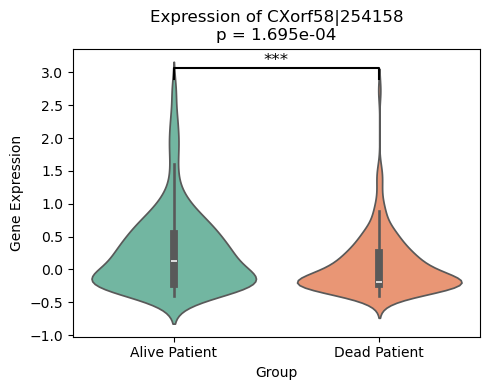

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_35406/4176055470.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')


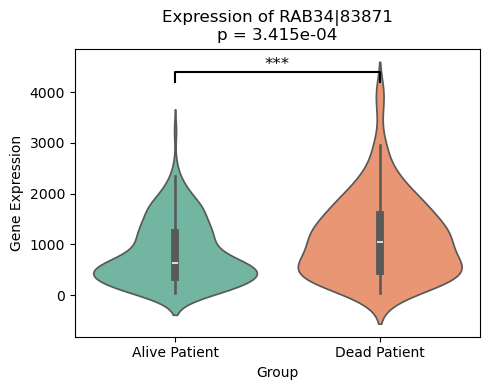

In [130]:
# NRP1|8829
# CXorf58|254158
# RAB34|83871

genes = ['NRP1|8829', 'CXorf58|254158', 'RAB34|83871']
for gene_id in genes:
    # Subset to get expression values as Series (1D)
    alive = low_exp_matrix[low_exp_matrix.index.isin(y[y == 0].index)][gene_id].squeeze()
    dead = low_exp_matrix[low_exp_matrix.index.isin(y[y == 1].index)][gene_id].squeeze()

    # Prepare DataFrame for plotting
    plot_df = pd.DataFrame({
        'Gene Expression': pd.concat([alive, dead]),
        'Group': ['Alive Patient'] * len(alive) + ['Dead Patient'] * len(dead)
    })

    # Perform Mann-Whitney U test
    stat, p_value = mannwhitneyu(alive, dead, alternative='two-sided')

    # Determine significance marker
    if p_value < 0.001:
        sig_marker = '***'
    elif p_value < 0.01:
        sig_marker = '**'
    elif p_value < 0.05:
        sig_marker = '*'
    else:
        sig_marker = 'ns'  # Not significant

    # Plot
    plt.figure(figsize=(5, 4))
    sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')

    # Add significance annotation
    # Get y-axis limits to place the annotation
    y_max = plot_df['Gene Expression'].max()
    y_range = plot_df['Gene Expression'].max() - plot_df['Gene Expression'].min()
    y_pos = y_max + y_range * 0.1  # Position slightly above the highest violin

    # Draw a line connecting the two groups
    x1, x2 = 0, 1  # x positions for 'Alive Patient' and 'Dead Patient'
    plt.plot([x1, x1, x2, x2], [y_pos - y_range * 0.05, y_pos, y_pos, y_pos - y_range * 0.05], lw=1.5, color='black')

    # Add the significance marker above the line
    plt.text((x1 + x2) / 2, y_pos, sig_marker, ha='center', va='bottom', color='black', fontsize=12)

    # Customize plot
    plt.title(f"Expression of {gene_id}\np = {p_value:.3e}")
    plt.tight_layout()
    plt.show()

# Low DFI

(141, 3210)
(141, 3210)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 3, 'min_samples_split': 4, 'n_estimators': 100}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 2, 'solver': 'newton-cg'}

Training SVM...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.732026  0.344538  0.790698   0.500000  0.111111   
1  Logistic Regression  0.784314  0.565059  0.767442   0.428571  0.333333   
2                  SVM  0.771242  0.554971  0.767442   0.428571  0.333333   

         F1  
0  0.181818  
1  0.375000  
2  0.375000  


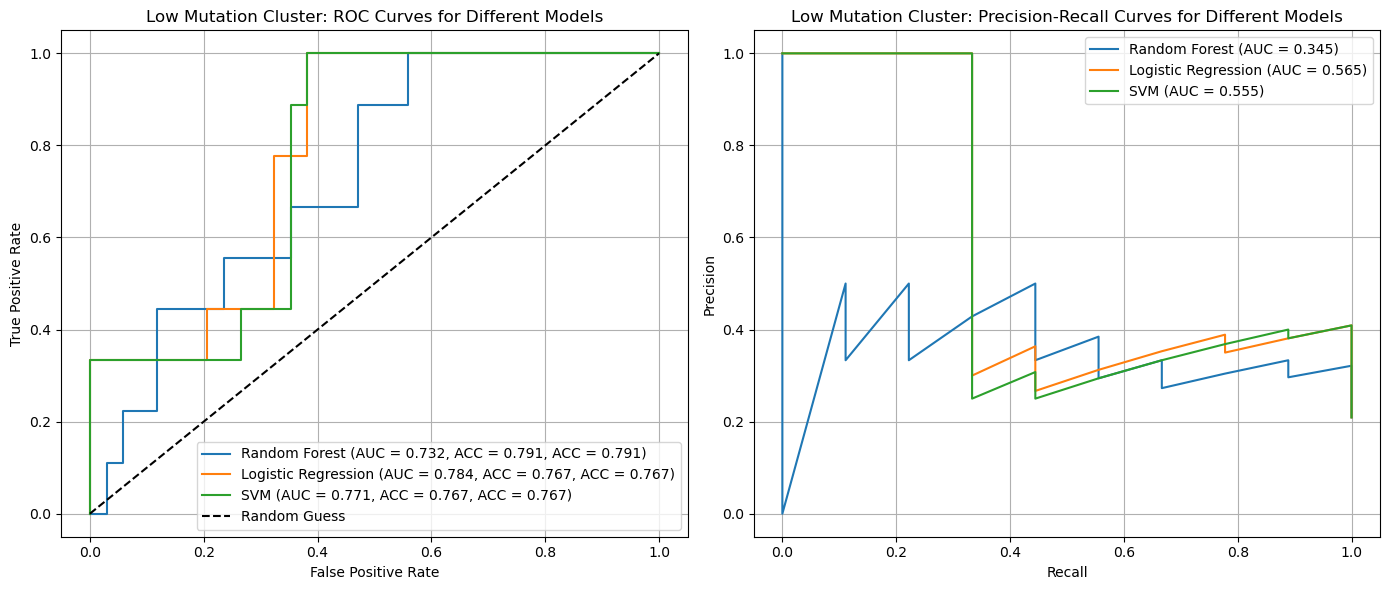

In [146]:
low_mut_metadata = metadata[metadata.index.isin(low_mut.patient_id)]
os_0 = low_mut_metadata[low_mut_metadata.OS == 0].sample(n=130, random_state=42)
os_1 = low_mut_metadata[low_mut_metadata.OS == 1].sample(n=130, random_state=42)
low_mut_metadata = pd.concat([os_0, os_1])

low_mut_patients = set(low_mut_metadata.index)
low_mutation_matrix = pd.crosstab(
    index=low_mut['patient_id'],
    columns=low_mut['Hugo_Symbol'],
    values=1, 
    aggfunc='count'
)
low_mutation_matrix = low_mutation_matrix.fillna(0)
low_mutation_matrix = low_mutation_matrix[low_mutation_matrix.index.isin(low_mut_patients)]
low_exp_matrix = expression[expression.index.isin(low_mut_patients)]

low_metadata = low_mut_metadata.dropna(subset=['DFI', 'DFI.time'])
low_metadata['y'] = low_metadata['DFI']

common_patients = low_metadata.index.intersection(low_mutation_matrix.index).intersection(low_exp_matrix.index)
X_mut = low_mutation_matrix.loc[common_patients]
X_exp = low_exp_matrix.loc[common_patients]
X_clinical = low_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                 'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                 'histological_grade', 'tumor_status']]
y = low_metadata.loc[common_patients, 'y']

# Step 3: Feature Selection
# 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
mutation_freq = X_mut.mean()
selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
X_mut_selected = X_mut[selected_mut_genes]

# 3.2: Gene Expression Features - Standardize and filter low-variance genes
scaler = StandardScaler()
X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
exp_variance = X_exp_scaled.var()
selected_exp_genes = exp_variance[exp_variance > 0.01].index  # Keep genes with variance > 0.01
X_exp_selected = X_exp_scaled[selected_exp_genes]

# 3.3: Clinical Features - Encode categorical variables
# Define which columns are categorical
categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
numerical_cols = ['age_at_initial_pathologic_diagnosis']

# Use ColumnTransformer to encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

X_clinical_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_clinical),
    index=X_clinical.index,
    columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
)

# 3.4: Univariate Feature Selection for Mutation and Expression Features
# For binary features (mutation), use chi-squared test
mut_p_values = {}
for col in X_mut_selected.columns:
    contingency_table = pd.crosstab(X_mut_selected[col], y)
    chi2, p, _, _ = chi2_contingency(contingency_table)
    mut_p_values[col] = p

# t-test
exp_p_values = {}
for col in X_exp_selected.columns:
    group0 = X_exp_selected[col][y == 0]
    group1 = X_exp_selected[col][y == 1]
    t_stat, p = ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
    exp_p_values[col] = p

# Select features
selected_mut_features = [col for col, p in mut_p_values.items() if p < 0.1]
selected_exp_features = [col for col, p in exp_p_values.items() if p < 0.1]
X_mut_final = X_mut_selected[selected_mut_features]
X_exp_final = X_exp_selected[selected_exp_features]

X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)
print(X.shape)

X = X.dropna()
print(X.shape)

y = y[y.index.isin(X.index)]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Sanitize feature names to remove problematic characters (e.g., [], <)
X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

# Step 5: Train Multiple Models with Cross-Validation
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
    'SVM': SVC(probability=True, random_state=42),
    # 'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    # 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    # 'KNN': KNeighborsClassifier(),
    # 'Decision Tree': DecisionTreeClassifier(random_state=42)
}
# Hyperparameter grids for tuning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 200, 250, 300],
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 3, 4, 5]
    },
    'Logistic Regression': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
    },
    'SVM': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'kernel': ['rbf', 'linear']
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 3, 4, 5],
        'min_samples_leaf': [1, 2, 3]
    }
}

# Dictionary to store the best models and their performance
best_models = {}
metrics = {'Model': [], 'AUC-ROC': [], 'AUC-PR': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
roc_data = {}
pr_data = {}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    print(f"Best parameters for {model_name}:", grid_search.best_params_)
    
    # Predictions and probabilities
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)
    
    # Compute metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[model_name] = (fpr, tpr, auc_roc, accuracy)
    
    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    auc_pr = auc(recall_vals, precision_vals)
    pr_data[model_name] = (recall_vals, precision_vals, auc_pr)
    
    # Store metrics
    metrics['Model'].append(model_name)
    metrics['AUC-ROC'].append(auc_roc)
    metrics['AUC-PR'].append(auc_pr)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1'].append(f1)

# Print metrics in a table
metrics_df = pd.DataFrame(metrics)
print("\nModel Performance Comparison:")
print(metrics_df)

# Plot ROC and Precision-Recall Curves side by side
plt.figure(figsize=(14, 6))

# ROC Curves (Left subplot)
plt.subplot(1, 2, 1)
for model_name, (fpr, tpr, auc_roc, acc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.3f}, ACC = {acc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Low Mutation Cluster: ROC Curves for Different Models')
plt.legend()
plt.grid()

# Precision-Recall Curves (Right subplot)
plt.subplot(1, 2, 2)
for model_name, (recall_vals, precision_vals, auc_pr) in pr_data.items():
    plt.plot(recall_vals, precision_vals, label=f'{model_name} (AUC = {auc_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Low Mutation Cluster: Precision-Recall Curves for Different Models')
plt.legend()
plt.grid()

# Adjust layout and save
plt.tight_layout()
plt.show()

# Low OS pvalue < 0.1

(256, 1700)
(256, 1700)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 3, 'n_estimators': 300}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 4, 'solver': 'newton-cg'}

Training SVM...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.695682  0.594085  0.675325   0.666667  0.684211   
1  Logistic Regression  0.874494  0.874109  0.805195   0.828571  0.763158   
2                  SVM  0.858974  0.874590  0.844156   0.882353  0.789474   

         F1  
0  0.675325  
1  0.794521  
2  0.833333  


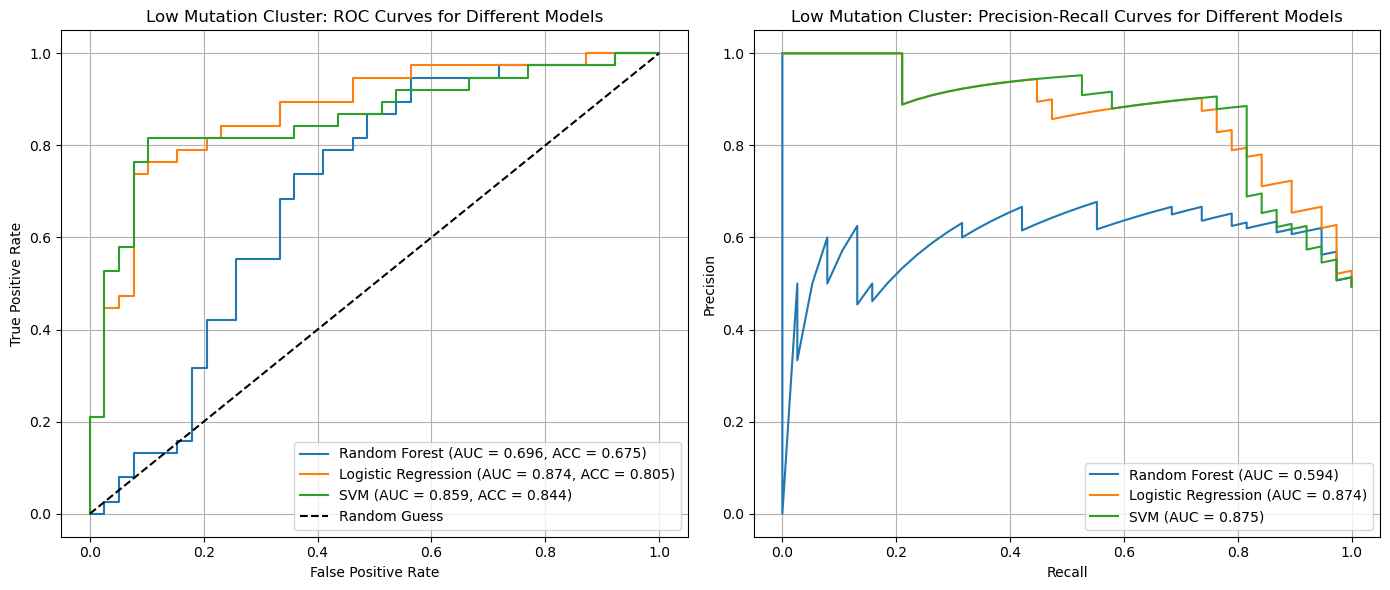

In [150]:
low_mut_metadata = metadata[metadata.index.isin(low_mut.patient_id)]
os_0 = low_mut_metadata[low_mut_metadata.OS == 0].sample(n=130, random_state=42)
os_1 = low_mut_metadata[low_mut_metadata.OS == 1].sample(n=130, random_state=42)
low_mut_metadata = pd.concat([os_0, os_1])

low_mut_patients = set(low_mut_metadata.index)
low_mutation_matrix = pd.crosstab(
    index=low_mut['patient_id'],
    columns=low_mut['Hugo_Symbol'],
    values=1, 
    aggfunc='count'
)
low_mutation_matrix = low_mutation_matrix.fillna(0)
low_mutation_matrix = low_mutation_matrix[low_mutation_matrix.index.isin(low_mut_patients)]
low_exp_matrix = expression[expression.index.isin(low_mut_patients)]

low_metadata = low_mut_metadata.dropna(subset=['OS', 'OS.time'])
low_metadata['y'] = low_metadata['OS']

common_patients = low_metadata.index.intersection(low_mutation_matrix.index).intersection(low_exp_matrix.index)
X_mut = low_mutation_matrix.loc[common_patients]
X_exp = low_exp_matrix.loc[common_patients]
X_clinical = low_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                 'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                 'histological_grade', 'tumor_status']]
y = low_metadata.loc[common_patients, 'y']

# Step 3: Feature Selection
# 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
mutation_freq = X_mut.mean()
selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
X_mut_selected = X_mut[selected_mut_genes]

# 3.2: Gene Expression Features - Standardize and filter low-variance genes
scaler = StandardScaler()
X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
exp_variance = X_exp_scaled.var()
selected_exp_genes = exp_variance[exp_variance > 0.01].index  # Keep genes with variance > 0.01
X_exp_selected = X_exp_scaled[selected_exp_genes]

# 3.3: Clinical Features - Encode categorical variables
# Define which columns are categorical
categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
numerical_cols = ['age_at_initial_pathologic_diagnosis']

# Use ColumnTransformer to encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

X_clinical_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_clinical),
    index=X_clinical.index,
    columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
)

# 3.4: Univariate Feature Selection for Mutation and Expression Features
# For binary features (mutation), use chi-squared test
mut_p_values = {}
for col in X_mut_selected.columns:
    contingency_table = pd.crosstab(X_mut_selected[col], y)
    chi2, p, _, _ = chi2_contingency(contingency_table)
    mut_p_values[col] = p

# t-test
exp_p_values = {}
for col in X_exp_selected.columns:
    group0 = X_exp_selected[col][y == 0]
    group1 = X_exp_selected[col][y == 1]
    t_stat, p = ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
    exp_p_values[col] = p

# Select features
selected_mut_features = [col for col, p in mut_p_values.items() if p < 0.1]
selected_exp_features = [col for col, p in exp_p_values.items() if p < 0.1]
X_mut_final = X_mut_selected[selected_mut_features]
X_exp_final = X_exp_selected[selected_exp_features]

X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)
print(X.shape)

X = X.dropna()
print(X.shape)

y = y[y.index.isin(X.index)]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Sanitize feature names to remove problematic characters (e.g., [], <)
X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

# Step 5: Train Multiple Models with Cross-Validation
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
    'SVM': SVC(probability=True, random_state=42),
    # 'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    # 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    # 'KNN': KNeighborsClassifier(),
    # 'Decision Tree': DecisionTreeClassifier(random_state=42)
}
# Hyperparameter grids for tuning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 200, 250, 300],
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 3, 4, 5]
    },
    'Logistic Regression': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
    },
    'SVM': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'kernel': ['rbf', 'linear']
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 3, 4, 5],
        'min_samples_leaf': [1, 2, 3]
    }
}
# Dictionary to store the best models and their performance
best_models = {}
metrics = {'Model': [], 'AUC-ROC': [], 'AUC-PR': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
roc_data = {}
pr_data = {}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    print(f"Best parameters for {model_name}:", grid_search.best_params_)
    
    # Predictions and probabilities
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)
    
    # Compute metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[model_name] = (fpr, tpr, auc_roc, accuracy)
    
    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    auc_pr = auc(recall_vals, precision_vals)
    pr_data[model_name] = (recall_vals, precision_vals, auc_pr)
    
    # Store metrics
    metrics['Model'].append(model_name)
    metrics['AUC-ROC'].append(auc_roc)
    metrics['AUC-PR'].append(auc_pr)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1'].append(f1)

# Print metrics in a table
metrics_df = pd.DataFrame(metrics)
print("\nModel Performance Comparison:")
print(metrics_df)

# Plot ROC and Precision-Recall Curves side by side
plt.figure(figsize=(14, 6))

# ROC Curves (Left subplot)
plt.subplot(1, 2, 1)
for model_name, (fpr, tpr, auc_roc, acc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.3f}, ACC = {acc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Low Mutation Cluster: ROC Curves for Different Models')
plt.legend()
plt.grid()

# Precision-Recall Curves (Right subplot)
plt.subplot(1, 2, 2)
for model_name, (recall_vals, precision_vals, auc_pr) in pr_data.items():
    plt.plot(recall_vals, precision_vals, label=f'{model_name} (AUC = {auc_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Low Mutation Cluster: Precision-Recall Curves for Different Models')
plt.legend()
plt.grid()

# Adjust layout and save
plt.tight_layout()
plt.show()

# Low OS pvalue < 0.05

(256, 782)
(256, 782)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 150}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 8, 'solver': 'newton-cg'}

Training SVM...
Best parameters for SVM: {'C': 8, 'kernel': 'rbf'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.701080  0.587491  0.675325   0.666667  0.684211   
1  Logistic Regression  0.885290  0.869361  0.831169   0.857143  0.789474   
2                  SVM  0.896761  0.860149  0.844156   0.842105  0.842105   

         F1  
0  0.675325  
1  0.821918  
2  0.842105  


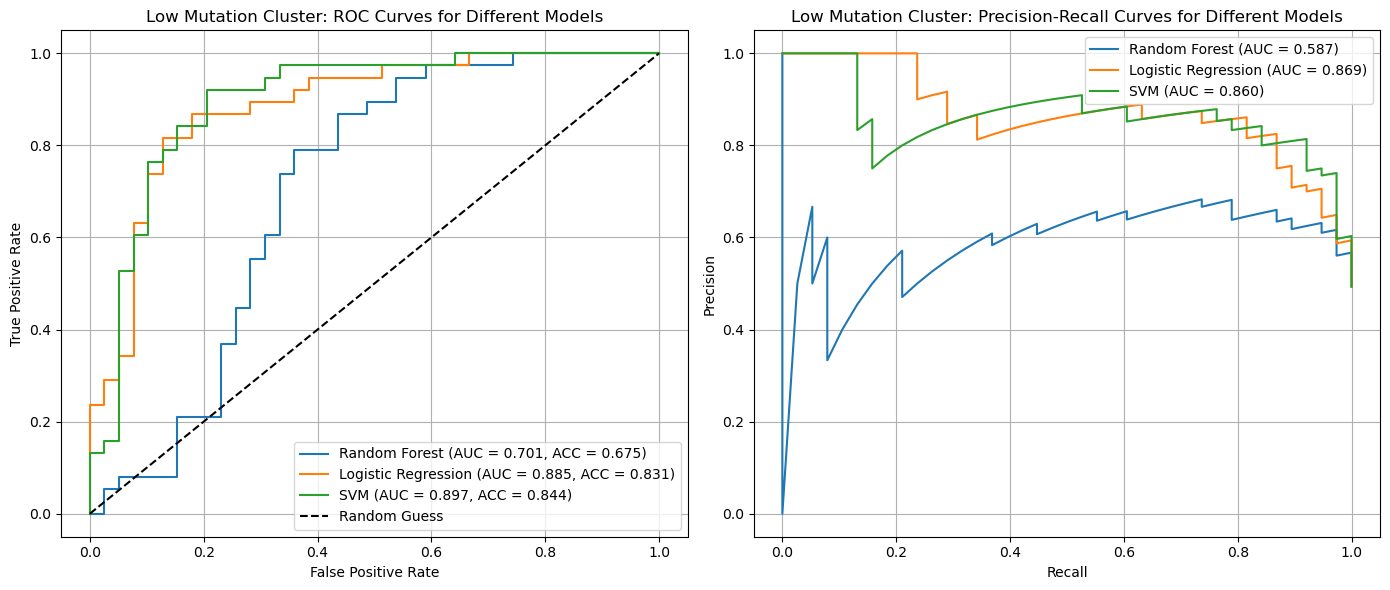

In [151]:
low_mut_metadata = metadata[metadata.index.isin(low_mut.patient_id)]
os_0 = low_mut_metadata[low_mut_metadata.OS == 0].sample(n=130, random_state=42)
os_1 = low_mut_metadata[low_mut_metadata.OS == 1].sample(n=130, random_state=42)
low_mut_metadata = pd.concat([os_0, os_1])

low_mut_patients = set(low_mut_metadata.index)
low_mutation_matrix = pd.crosstab(
    index=low_mut['patient_id'],
    columns=low_mut['Hugo_Symbol'],
    values=1, 
    aggfunc='count'
)
low_mutation_matrix = low_mutation_matrix.fillna(0)
low_mutation_matrix = low_mutation_matrix[low_mutation_matrix.index.isin(low_mut_patients)]
low_exp_matrix = expression[expression.index.isin(low_mut_patients)]

low_metadata = low_mut_metadata.dropna(subset=['OS', 'OS.time'])
low_metadata['y'] = low_metadata['OS']

common_patients = low_metadata.index.intersection(low_mutation_matrix.index).intersection(low_exp_matrix.index)
X_mut = low_mutation_matrix.loc[common_patients]
X_exp = low_exp_matrix.loc[common_patients]
X_clinical = low_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                 'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                 'histological_grade', 'tumor_status']]
y = low_metadata.loc[common_patients, 'y']

# Step 3: Feature Selection
# 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
mutation_freq = X_mut.mean()
selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
X_mut_selected = X_mut[selected_mut_genes]

# 3.2: Gene Expression Features - Standardize and filter low-variance genes
scaler = StandardScaler()
X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
exp_variance = X_exp_scaled.var()
selected_exp_genes = exp_variance[exp_variance > 0.01].index  # Keep genes with variance > 0.01
X_exp_selected = X_exp_scaled[selected_exp_genes]

# 3.3: Clinical Features - Encode categorical variables
# Define which columns are categorical
categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
numerical_cols = ['age_at_initial_pathologic_diagnosis']

# Use ColumnTransformer to encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

X_clinical_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_clinical),
    index=X_clinical.index,
    columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
)

# 3.4: Univariate Feature Selection for Mutation and Expression Features
# For binary features (mutation), use chi-squared test
mut_p_values = {}
for col in X_mut_selected.columns:
    contingency_table = pd.crosstab(X_mut_selected[col], y)
    chi2, p, _, _ = chi2_contingency(contingency_table)
    mut_p_values[col] = p

# t-test
exp_p_values = {}
for col in X_exp_selected.columns:
    group0 = X_exp_selected[col][y == 0]
    group1 = X_exp_selected[col][y == 1]
    t_stat, p = ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
    exp_p_values[col] = p

# Select features
selected_mut_features = [col for col, p in mut_p_values.items() if p < 0.05]
selected_exp_features = [col for col, p in exp_p_values.items() if p < 0.05]
X_mut_final = X_mut_selected[selected_mut_features]
X_exp_final = X_exp_selected[selected_exp_features]

X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)
print(X.shape)

X = X.dropna()
print(X.shape)

y = y[y.index.isin(X.index)]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Sanitize feature names to remove problematic characters (e.g., [], <)
X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

# Step 5: Train Multiple Models with Cross-Validation
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
    'SVM': SVC(probability=True, random_state=42),
    # 'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    # 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    # 'KNN': KNeighborsClassifier(),
    # 'Decision Tree': DecisionTreeClassifier(random_state=42)
}
# Hyperparameter grids for tuning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 200, 250, 300],
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 3, 4, 5]
    },
    'Logistic Regression': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
    },
    'SVM': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'kernel': ['rbf', 'linear']
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 3, 4, 5],
        'min_samples_leaf': [1, 2, 3]
    }
}
# Dictionary to store the best models and their performance
best_models = {}
metrics = {'Model': [], 'AUC-ROC': [], 'AUC-PR': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
roc_data = {}
pr_data = {}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    print(f"Best parameters for {model_name}:", grid_search.best_params_)
    
    # Predictions and probabilities
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)
    
    # Compute metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[model_name] = (fpr, tpr, auc_roc, accuracy)
    
    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    auc_pr = auc(recall_vals, precision_vals)
    pr_data[model_name] = (recall_vals, precision_vals, auc_pr)
    
    # Store metrics
    metrics['Model'].append(model_name)
    metrics['AUC-ROC'].append(auc_roc)
    metrics['AUC-PR'].append(auc_pr)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1'].append(f1)

# Print metrics in a table
metrics_df = pd.DataFrame(metrics)
print("\nModel Performance Comparison:")
print(metrics_df)

# Plot ROC and Precision-Recall Curves side by side
plt.figure(figsize=(14, 6))

# ROC Curves (Left subplot)
plt.subplot(1, 2, 1)
for model_name, (fpr, tpr, auc_roc, acc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.3f}, ACC = {acc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Low Mutation Cluster: ROC Curves for Different Models')
plt.legend()
plt.grid()

# Precision-Recall Curves (Right subplot)
plt.subplot(1, 2, 2)
for model_name, (recall_vals, precision_vals, auc_pr) in pr_data.items():
    plt.plot(recall_vals, precision_vals, label=f'{model_name} (AUC = {auc_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Low Mutation Cluster: Precision-Recall Curves for Different Models')
plt.legend()
plt.grid()

# Adjust layout and save
plt.tight_layout()
plt.show()

# Low OS pvalue < 0.01

(256, 138)
(256, 138)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 7, 'min_samples_split': 4, 'n_estimators': 150}

Training Logistic Regression...


/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}

Training SVM...
Best parameters for SVM: {'C': 10, 'kernel': 'rbf'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.802969  0.762650  0.740260   0.704545  0.815789   
1  Logistic Regression  0.884615  0.869242  0.779221   0.838710  0.684211   
2                  SVM  0.849528  0.824968  0.753247   0.756757  0.736842   

         F1  
0  0.756098  
1  0.753623  
2  0.746667  


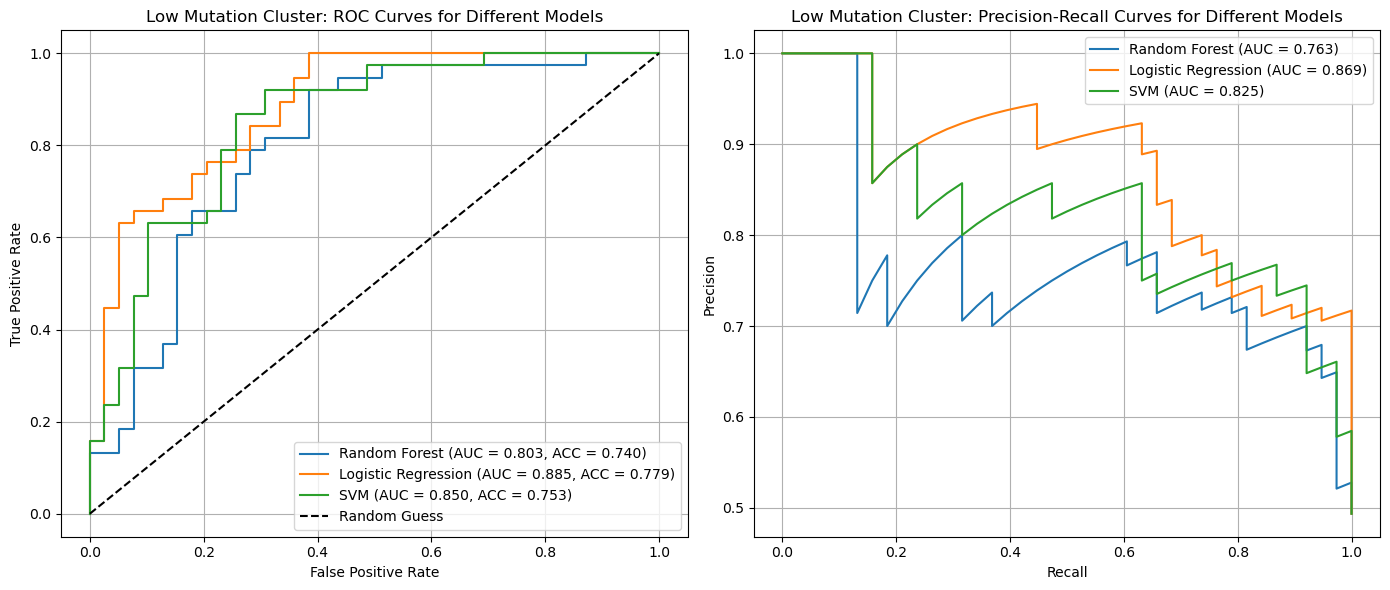

In [152]:
low_mut_metadata = metadata[metadata.index.isin(low_mut.patient_id)]
os_0 = low_mut_metadata[low_mut_metadata.OS == 0].sample(n=130, random_state=42)
os_1 = low_mut_metadata[low_mut_metadata.OS == 1].sample(n=130, random_state=42)
low_mut_metadata = pd.concat([os_0, os_1])

low_mut_patients = set(low_mut_metadata.index)
low_mutation_matrix = pd.crosstab(
    index=low_mut['patient_id'],
    columns=low_mut['Hugo_Symbol'],
    values=1, 
    aggfunc='count'
)
low_mutation_matrix = low_mutation_matrix.fillna(0)
low_mutation_matrix = low_mutation_matrix[low_mutation_matrix.index.isin(low_mut_patients)]
low_exp_matrix = expression[expression.index.isin(low_mut_patients)]

low_metadata = low_mut_metadata.dropna(subset=['OS', 'OS.time'])
low_metadata['y'] = low_metadata['OS']

common_patients = low_metadata.index.intersection(low_mutation_matrix.index).intersection(low_exp_matrix.index)
X_mut = low_mutation_matrix.loc[common_patients]
X_exp = low_exp_matrix.loc[common_patients]
X_clinical = low_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                 'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                 'histological_grade', 'tumor_status']]
y = low_metadata.loc[common_patients, 'y']

# Step 3: Feature Selection
# 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
mutation_freq = X_mut.mean()
selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
X_mut_selected = X_mut[selected_mut_genes]

# 3.2: Gene Expression Features - Standardize and filter low-variance genes
scaler = StandardScaler()
X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
exp_variance = X_exp_scaled.var()
selected_exp_genes = exp_variance[exp_variance > 0.01].index  # Keep genes with variance > 0.01
X_exp_selected = X_exp_scaled[selected_exp_genes]

# 3.3: Clinical Features - Encode categorical variables
# Define which columns are categorical
categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
numerical_cols = ['age_at_initial_pathologic_diagnosis']

# Use ColumnTransformer to encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

X_clinical_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_clinical),
    index=X_clinical.index,
    columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
)

# 3.4: Univariate Feature Selection for Mutation and Expression Features
# For binary features (mutation), use chi-squared test
mut_p_values = {}
for col in X_mut_selected.columns:
    contingency_table = pd.crosstab(X_mut_selected[col], y)
    chi2, p, _, _ = chi2_contingency(contingency_table)
    mut_p_values[col] = p

# t-test
exp_p_values = {}
for col in X_exp_selected.columns:
    group0 = X_exp_selected[col][y == 0]
    group1 = X_exp_selected[col][y == 1]
    t_stat, p = ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
    exp_p_values[col] = p

# Select features
selected_mut_features = [col for col, p in mut_p_values.items() if p < 0.01]
selected_exp_features = [col for col, p in exp_p_values.items() if p < 0.01]
X_mut_final = X_mut_selected[selected_mut_features]
X_exp_final = X_exp_selected[selected_exp_features]

X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)
print(X.shape)

X = X.dropna()
print(X.shape)

y = y[y.index.isin(X.index)]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Sanitize feature names to remove problematic characters (e.g., [], <)
X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

# Step 5: Train Multiple Models with Cross-Validation
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
    'SVM': SVC(probability=True, random_state=42),
    # 'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    # 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    # 'KNN': KNeighborsClassifier(),
    # 'Decision Tree': DecisionTreeClassifier(random_state=42)
}
# Hyperparameter grids for tuning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 200, 250, 300],
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 3, 4, 5]
    },
    'Logistic Regression': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
    },
    'SVM': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'kernel': ['rbf', 'linear']
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 3, 4, 5],
        'min_samples_leaf': [1, 2, 3]
    }
}
# Dictionary to store the best models and their performance
best_models = {}
metrics = {'Model': [], 'AUC-ROC': [], 'AUC-PR': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
roc_data = {}
pr_data = {}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    print(f"Best parameters for {model_name}:", grid_search.best_params_)
    
    # Predictions and probabilities
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)
    
    # Compute metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[model_name] = (fpr, tpr, auc_roc, accuracy)
    
    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    auc_pr = auc(recall_vals, precision_vals)
    pr_data[model_name] = (recall_vals, precision_vals, auc_pr)
    
    # Store metrics
    metrics['Model'].append(model_name)
    metrics['AUC-ROC'].append(auc_roc)
    metrics['AUC-PR'].append(auc_pr)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1'].append(f1)

# Print metrics in a table
metrics_df = pd.DataFrame(metrics)
print("\nModel Performance Comparison:")
print(metrics_df)

# Plot ROC and Precision-Recall Curves side by side
plt.figure(figsize=(14, 6))

# ROC Curves (Left subplot)
plt.subplot(1, 2, 1)
for model_name, (fpr, tpr, auc_roc, acc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.3f}, ACC = {acc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Low Mutation Cluster: ROC Curves for Different Models')
plt.legend()
plt.grid()

# Precision-Recall Curves (Right subplot)
plt.subplot(1, 2, 2)
for model_name, (recall_vals, precision_vals, auc_pr) in pr_data.items():
    plt.plot(recall_vals, precision_vals, label=f'{model_name} (AUC = {auc_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Low Mutation Cluster: Precision-Recall Curves for Different Models')
plt.legend()
plt.grid()

# Adjust layout and save
plt.tight_layout()
plt.show()

In [119]:
for model_name in ['Random Forest']:
    if model_name in best_models:
        print(f"\nTop 10 Most Important Features for {model_name}:")
        model = best_models[model_name]
        feature_importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
        print(feature_importance.head(20))


Top 10 Most Important Features for Random Forest:
tumor_status_WITH TUMOR    0.007933
TBC1D26|353149             0.003498
CYB561D1|284613            0.003238
ACTR2|10097                0.003151
IRAK1BP1|134728            0.003045
TK2|7084                   0.002949
LOC646762|646762           0.002838
SP6|80320                  0.002759
C12orf48|55010             0.002742
KIFC3|3801                 0.002690
FAM38B|63895               0.002685
ZCWPW1|55063               0.002681
NR1D1|9572                 0.002674
TFPI2|7980                 0.002672
NME1-NME2|654364           0.002655
ZNF433|163059              0.002567
THPO|7066                  0.002545
PITX3|5309                 0.002544
CCPG1|9236                 0.002535
BDNFOS|497258              0.002535
dtype: float64


In [121]:
# dict(sorted(exp_p_values.items(), key=lambda x: x[1]))

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_35406/3388848707.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')


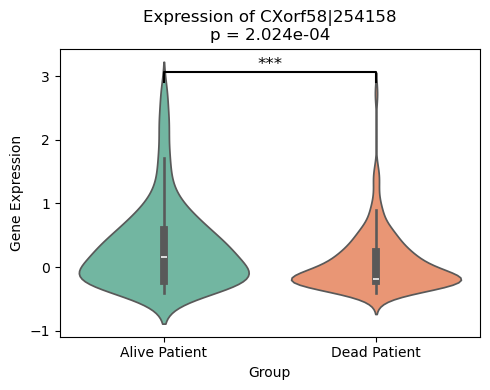

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_35406/3388848707.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')


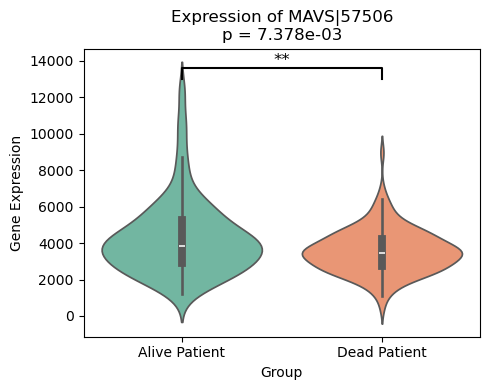

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_35406/3388848707.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')


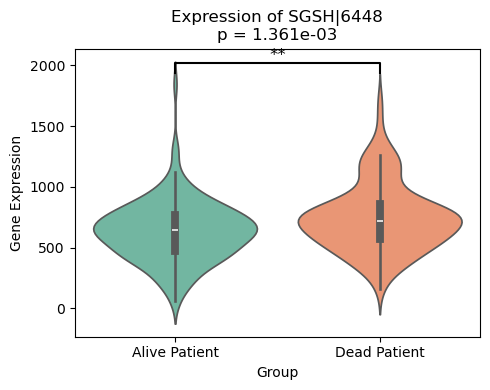

In [123]:
# CXorf58|254158
# MAVS|57506
# SGSH|6448
genes = ['CXorf58|254158', 'MAVS|57506', 'SGSH|6448']
for gene_id in genes:
    # Subset to get expression values as Series (1D)
    alive = low_exp_matrix[low_exp_matrix.index.isin(y[y == 0].index)][gene_id].squeeze()
    dead = low_exp_matrix[low_exp_matrix.index.isin(y[y == 1].index)][gene_id].squeeze()

    # Prepare DataFrame for plotting
    plot_df = pd.DataFrame({
        'Gene Expression': pd.concat([alive, dead]),
        'Group': ['Alive Patient'] * len(alive) + ['Dead Patient'] * len(dead)
    })

    # Perform Mann-Whitney U test
    stat, p_value = mannwhitneyu(alive, dead, alternative='two-sided')

    # Determine significance marker
    if p_value < 0.001:
        sig_marker = '***'
    elif p_value < 0.01:
        sig_marker = '**'
    elif p_value < 0.05:
        sig_marker = '*'
    else:
        sig_marker = 'ns'  # Not significant

    # Plot
    plt.figure(figsize=(5, 4))
    sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')

    # Add significance annotation
    # Get y-axis limits to place the annotation
    y_max = plot_df['Gene Expression'].max()
    y_range = plot_df['Gene Expression'].max() - plot_df['Gene Expression'].min()
    y_pos = y_max + y_range * 0.1  # Position slightly above the highest violin

    # Draw a line connecting the two groups
    x1, x2 = 0, 1  # x positions for 'Alive Patient' and 'Dead Patient'
    plt.plot([x1, x1, x2, x2], [y_pos - y_range * 0.05, y_pos, y_pos, y_pos - y_range * 0.05], lw=1.5, color='black')

    # Add the significance marker above the line
    plt.text((x1 + x2) / 2, y_pos, sig_marker, ha='center', va='bottom', color='black', fontsize=12)

    # Customize plot
    plt.title(f"Expression of {gene_id}\np = {p_value:.3e}")
    plt.tight_layout()
    plt.show()

# High

(85, 2800)
(84, 2800)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 3, 'min_samples_split': 3, 'n_estimators': 200}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 1.5, 'solver': 'newton-cg'}

Training SVM...
Best parameters for SVM: {'C': 4, 'kernel': 'rbf'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision  Recall  \
0        Random Forest  0.680556  0.412141  0.653846   0.400000   0.250   
1  Logistic Regression  0.826389  0.802516  0.769231   0.625000   0.625   
2                  SVM  0.826389  0.790685  0.807692   0.714286   0.625   

         F1  
0  0.307692  
1  0.625000  
2  0.666667  


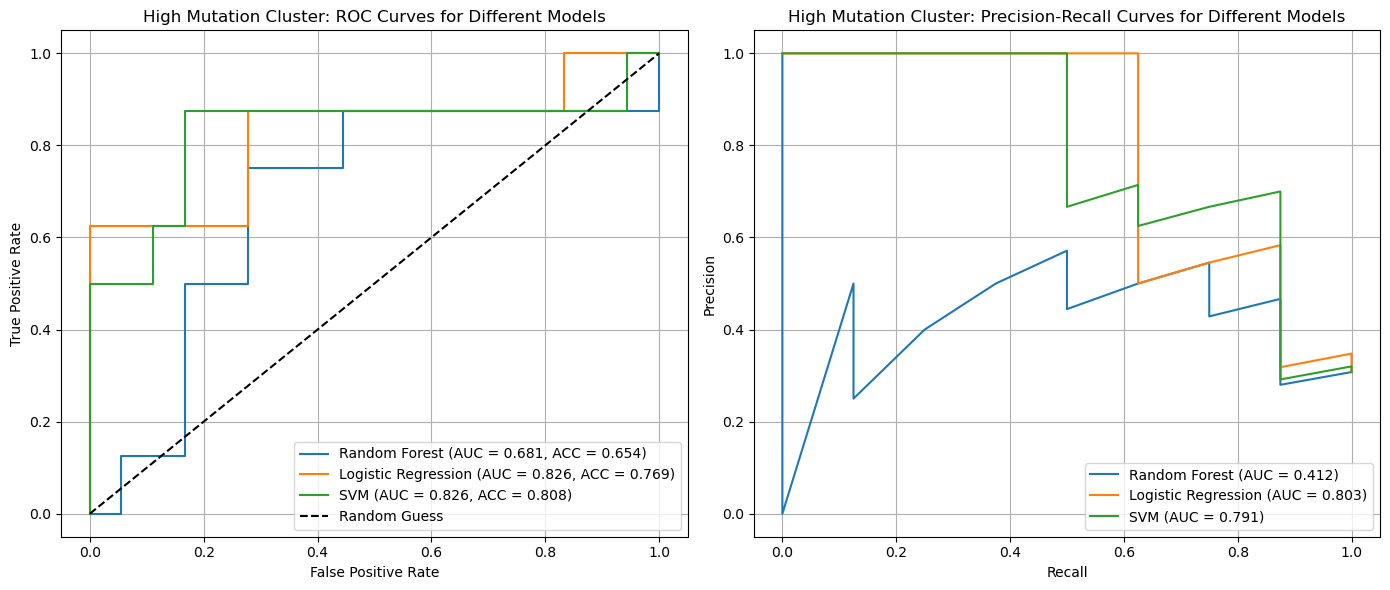

In [148]:
high_mut_metadata = metadata[metadata.index.isin(high_mut.patient_id)]
high_mut_patients = set(high_mut_metadata.index)
high_mutation_matrix = pd.crosstab(
    index=high_mut['patient_id'],
    columns=high_mut['Hugo_Symbol'],
    values=1, 
    aggfunc='count'
)
high_mutation_matrix = high_mutation_matrix.fillna(0)
high_mutation_matrix = high_mutation_matrix[high_mutation_matrix.index.isin(high_mut_patients)]
high_exp_matrix = expression[expression.index.isin(high_mut_patients)]

high_metadata = high_mut_metadata.dropna(subset=['OS', 'OS.time'])
high_metadata['y'] = high_metadata['OS']

common_patients = high_metadata.index.intersection(high_mutation_matrix.index).intersection(high_exp_matrix.index)
X_mut = high_mutation_matrix.loc[common_patients]
X_exp = high_exp_matrix.loc[common_patients]
X_clinical = high_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                 'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                 'histological_grade', 'tumor_status']]
y = high_metadata.loc[common_patients, 'y']

# Step 3: Feature Selection
# 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
mutation_freq = X_mut.mean()
selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
X_mut_selected = X_mut[selected_mut_genes]

# 3.2: Gene Expression Features - Standardize and filter low-variance genes
scaler = StandardScaler()
X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
exp_variance = X_exp_scaled.var()
selected_exp_genes = exp_variance[exp_variance > 0.01].index  # Keep genes with variance > 0.01
X_exp_selected = X_exp_scaled[selected_exp_genes]

# 3.3: Clinical Features - Encode categorical variables
# Define which columns are categorical
categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
numerical_cols = ['age_at_initial_pathologic_diagnosis']

# Use ColumnTransformer to encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

X_clinical_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_clinical),
    index=X_clinical.index,
    columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
)

# 3.4: Univariate Feature Selection for Mutation and Expression Features
# For binary features (mutation), use chi-squared test
mut_p_values = {}
for col in X_mut_selected.columns:
    contingency_table = pd.crosstab(X_mut_selected[col], y)
    chi2, p, _, _ = chi2_contingency(contingency_table)
    mut_p_values[col] = p

# t-test
exp_p_values = {}
for col in X_exp_selected.columns:
    group0 = X_exp_selected[col][y == 0]
    group1 = X_exp_selected[col][y == 1]
    t_stat, p = ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
    exp_p_values[col] = p

# Select features
selected_mut_features = [col for col, p in mut_p_values.items() if p < 0.1]
selected_exp_features = [col for col, p in exp_p_values.items() if p < 0.1]
X_mut_final = X_mut_selected[selected_mut_features]
X_exp_final = X_exp_selected[selected_exp_features]

X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)
print(X.shape)

X = X.dropna()
print(X.shape)

y = y[y.index.isin(X.index)]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Sanitize feature names to remove problematic characters (e.g., [], <)
X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

# Step 5: Train Multiple Models with Cross-Validation
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
    'SVM': SVC(probability=True, random_state=42),
    # 'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    # 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    # 'KNN': KNeighborsClassifier(),
    # 'Decision Tree': DecisionTreeClassifier(random_state=42)
}
# Hyperparameter grids for tuning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 200, 250, 300],
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 3, 4, 5]
    },
    'Logistic Regression': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
    },
    'SVM': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'kernel': ['rbf', 'linear']
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 3, 4, 5],
        'min_samples_leaf': [1, 2, 3]
    }
}

# Dictionary to store the best models and their performance
best_models = {}
metrics = {'Model': [], 'AUC-ROC': [], 'AUC-PR': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
roc_data = {}
pr_data = {}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    print(f"Best parameters for {model_name}:", grid_search.best_params_)
    
    # Predictions and probabilities
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)
    
    # Compute metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[model_name] = (fpr, tpr, auc_roc, accuracy)
    
    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    auc_pr = auc(recall_vals, precision_vals)
    pr_data[model_name] = (recall_vals, precision_vals, auc_pr)
    
    # Store metrics
    metrics['Model'].append(model_name)
    metrics['AUC-ROC'].append(auc_roc)
    metrics['AUC-PR'].append(auc_pr)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1'].append(f1)

# Print metrics in a table
metrics_df = pd.DataFrame(metrics)
print("\nModel Performance Comparison:")
print(metrics_df)

# Plot ROC and Precision-Recall Curves side by side
plt.figure(figsize=(14, 6))

# ROC Curves (Left subplot)
plt.subplot(1, 2, 1)
for model_name, (fpr, tpr, auc_roc, acc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.3f}, ACC = {acc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('High Mutation Cluster: ROC Curves for Different Models')
plt.legend()
plt.grid()

# Precision-Recall Curves (Right subplot)
plt.subplot(1, 2, 2)
for model_name, (recall_vals, precision_vals, auc_pr) in pr_data.items():
    plt.plot(recall_vals, precision_vals, label=f'{model_name} (AUC = {auc_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('High Mutation Cluster: Precision-Recall Curves for Different Models')
plt.legend()
plt.grid()

# Adjust layout and save
plt.tight_layout()
plt.show()

In [115]:
# dict(sorted(exp_p_values.items(), key=lambda x: x[1]))

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_35406/1121480923.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')


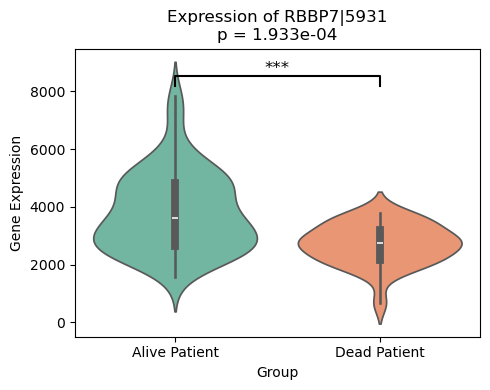

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_35406/1121480923.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')


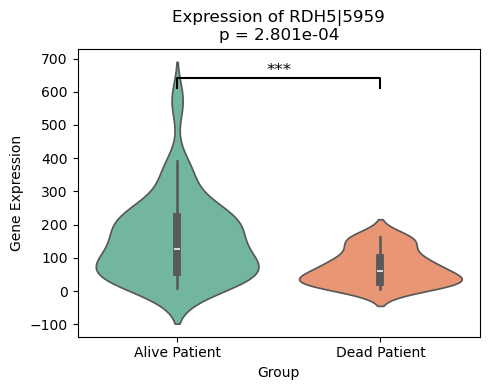

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_35406/1121480923.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')


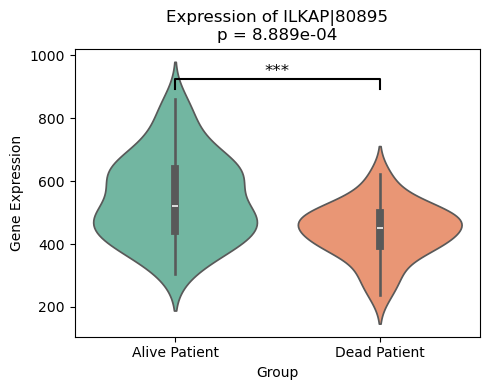

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import mannwhitneyu

genes = ['RBBP7|5931', 'RDH5|5959', 'ILKAP|80895']
for gene_id in genes:
    # Subset to get expression values as Series (1D)
    alive = high_exp_matrix[high_exp_matrix.index.isin(y[y == 0].index)][gene_id].squeeze()
    dead = high_exp_matrix[high_exp_matrix.index.isin(y[y == 1].index)][gene_id].squeeze()

    # Prepare DataFrame for plotting
    plot_df = pd.DataFrame({
        'Gene Expression': pd.concat([alive, dead]),
        'Group': ['Alive Patient'] * len(alive) + ['Dead Patient'] * len(dead)
    })

    # Perform Mann-Whitney U test
    stat, p_value = mannwhitneyu(alive, dead, alternative='two-sided')

    # Determine significance marker
    if p_value < 0.001:
        sig_marker = '***'
    elif p_value < 0.01:
        sig_marker = '**'
    elif p_value < 0.05:
        sig_marker = '*'
    else:
        sig_marker = 'ns'  # Not significant

    # Plot
    plt.figure(figsize=(5, 4))
    sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')

    # Add significance annotation
    # Get y-axis limits to place the annotation
    y_max = plot_df['Gene Expression'].max()
    y_range = plot_df['Gene Expression'].max() - plot_df['Gene Expression'].min()
    y_pos = y_max + y_range * 0.1  # Position slightly above the highest violin

    # Draw a line connecting the two groups
    x1, x2 = 0, 1  # x positions for 'Alive Patient' and 'Dead Patient'
    plt.plot([x1, x1, x2, x2], [y_pos - y_range * 0.05, y_pos, y_pos, y_pos - y_range * 0.05], lw=1.5, color='black')

    # Add the significance marker above the line
    plt.text((x1 + x2) / 2, y_pos, sig_marker, ha='center', va='bottom', color='black', fontsize=12)

    # Customize plot
    plt.title(f"Expression of {gene_id}\np = {p_value:.3e}")
    plt.tight_layout()
    plt.show()